<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part III · Visualizing Data &nbsp;|&nbsp; Chapter 14</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Charts for Categorical Data <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on showing how a total splits across categories: the bar chart and its variants, the truncated-axis trick that fools the eye, and why a sorted bar usually beats a pie.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | The workhorse bar chart | counts per category from value_counts |
| 2 | Sorted, horizontal bars | the fix for many or long labels |
| 3 | Grouped vs stacked | two ways to add a second category |
| 4 | How a chart lies | a truncated y-axis exaggerates differences |
| 5 | Pie vs bar | why length beats angle for reading values |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(14)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
# a colorblind-aware categorical palette (Okabe-Ito inspired)
CATS=[CYAN, AMBER, PURPLE, GREEN, PINK, BLUE]
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":13,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THE WORKHORSE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 A bar chart from counts</div>
<div style="color:#4a5578;margin-top:6px">Categorical data answers "how many in each category?" The bar chart encodes that count as a bar length on a common zero baseline, the encoding the eye reads most accurately. Note the gaps between bars: that signals distinct categories.</div>
</div>

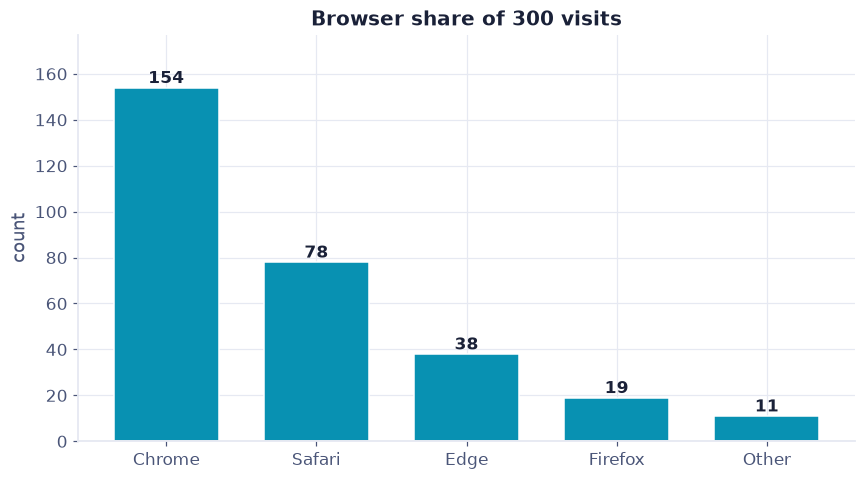

browser
Chrome     154
Safari      78
Edge        38
Firefox     19
Other       11


In [2]:
browsers = pd.Series(rng.choice(["Chrome","Safari","Edge","Firefox","Other"],
                     size=300, p=[0.55, 0.22, 0.12, 0.07, 0.04]), name="browser")
counts = browsers.value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(counts.index, counts.values, color=CYAN, edgecolor="white", width=0.7)
ax.set_title("Browser share of 300 visits"); ax.set_ylabel("count")
ax.set_ylim(0, counts.max()*1.15)        # bars start at ZERO
for i,v in enumerate(counts.values): ax.text(i, v+2, str(v), ha="center", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()
print(counts.to_string())

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · SORTED & HORIZONTAL</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📏 The fix for long or many labels</div>
<div style="color:#4a5578;margin-top:6px">When labels are long or there are many categories, swap the axes: horizontal bars read like a ranked list. For unordered (nominal) categories, sorting by value makes comparisons effortless.</div>
</div>

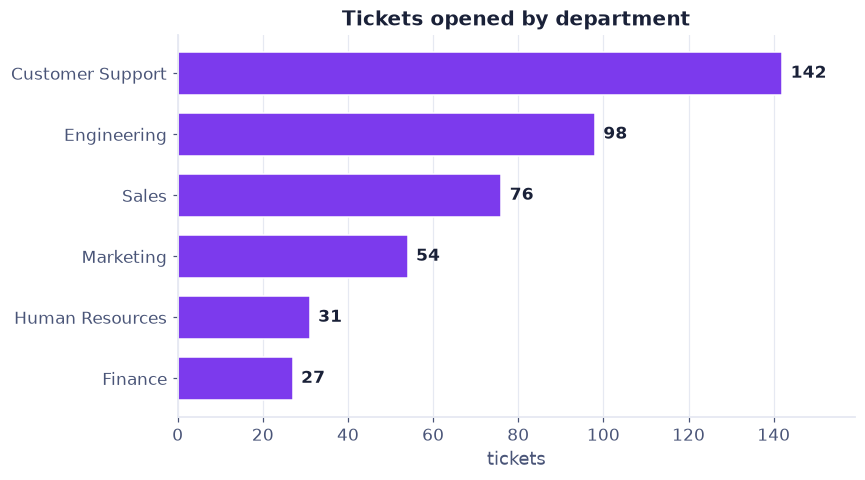

Horizontal + sorted: no rotated labels, instant ranking.


In [3]:
depts = pd.Series({"Customer Support":142,"Engineering":98,"Sales":76,
                   "Marketing":54,"Human Resources":31,"Finance":27})
depts = depts.sort_values()                # ascending -> biggest ends on top in barh

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(depts.index, depts.values, color=PURPLE, edgecolor="white", height=0.7)
ax.set_title("Tickets opened by department"); ax.set_xlabel("tickets")
ax.set_xlim(0, depts.max()*1.12)
for i,v in enumerate(depts.values): ax.text(v+2, i, str(v), va="center", fontweight="bold", color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("Horizontal + sorted: no rotated labels, instant ranking.")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · GROUPED VS STACKED</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧱 Adding a second category</div>
<div style="color:#4a5578;margin-top:6px">To split each category by a second variable you have two choices. Grouped bars share one baseline, so series compare precisely. Stacked bars show the total per category, but only the bottom segment sits on the baseline, so the floating upper segments are hard to compare.</div>
</div>

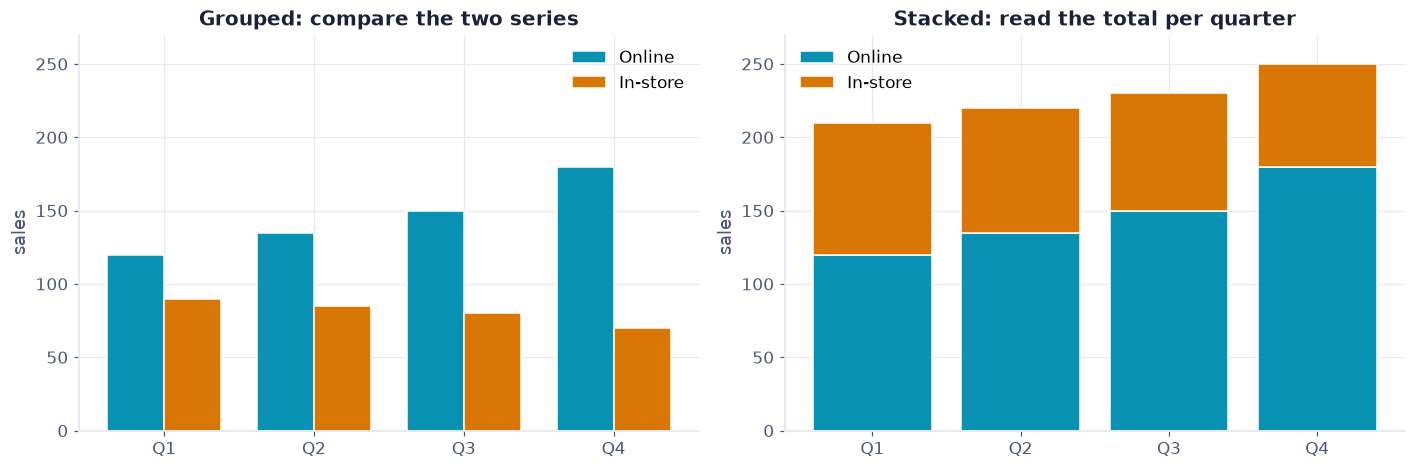

Grouped answers "which channel is bigger?"; stacked answers "what is the quarter total?"


In [4]:
quarters = ["Q1","Q2","Q3","Q4"]
online = np.array([120, 135, 150, 180])
store  = np.array([90,  85,  80,  70])
x = np.arange(len(quarters)); w = 0.38

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))

a1.bar(x-w/2, online, w, label="Online", color=CYAN, edgecolor="white")
a1.bar(x+w/2, store,  w, label="In-store", color=AMBER, edgecolor="white")
a1.set_title("Grouped: compare the two series"); a1.set_xticks(x); a1.set_xticklabels(quarters); a1.legend()

a2.bar(x, online, label="Online", color=CYAN, edgecolor="white")
a2.bar(x, store, bottom=online, label="In-store", color=AMBER, edgecolor="white")
a2.set_title("Stacked: read the total per quarter"); a2.set_xticks(x); a2.set_xticklabels(quarters); a2.legend()
for ax in (a1,a2): ax.set_ylabel("sales"); ax.set_ylim(0, 270)
plt.tight_layout(); plt.show()
print("Grouped answers \"which channel is bigger?\"; stacked answers \"what is the quarter total?\"")

<div style="background:#fde8ef;border-left:5px solid #db2777;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 4 · HOW A CHART LIES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🚨 The truncated y-axis</div>
<div style="color:#4a5578;margin-top:6px">Bars encode length from zero, so the value axis must start at 0. Cut the baseline and a tiny gap becomes a chasm. Same two numbers, two very different stories.</div>
</div>

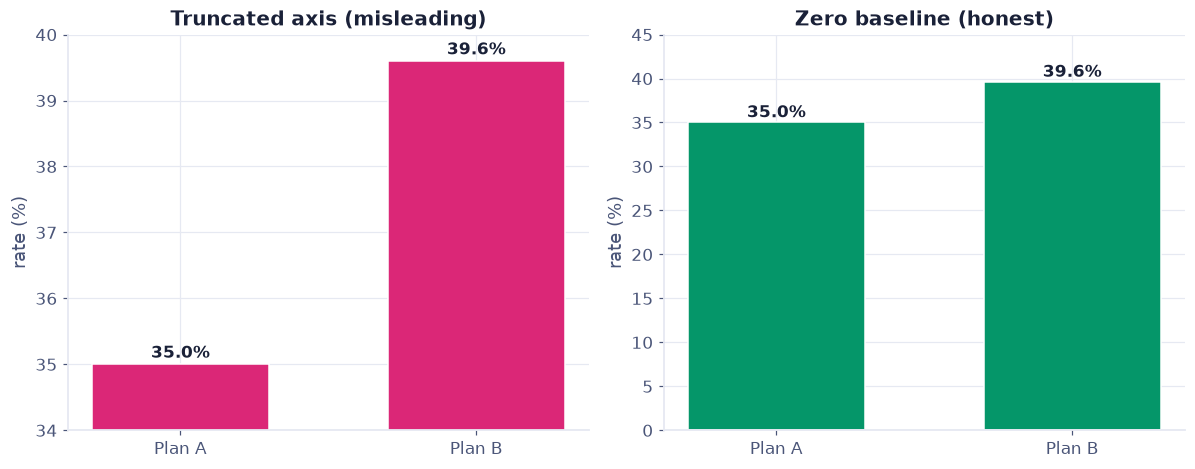

Real difference: 1.13x  (35.0% vs 39.6%)
The truncated chart makes Plan B look about 5.6x Plan A. That gap is manufactured by the axis.


In [5]:
labels = ["Plan A", "Plan B"]; vals = [35.0, 39.6]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar(labels, vals, color=PINK, edgecolor="white", width=0.6)
a1.set_ylim(34, 40)                       # TRUNCATED: misleading
a1.set_title("Truncated axis (misleading)"); a1.set_ylabel("rate (%)")

a2.bar(labels, vals, color=GREEN, edgecolor="white", width=0.6)
a2.set_ylim(0, 45)                        # honest zero baseline
a2.set_title("Zero baseline (honest)"); a2.set_ylabel("rate (%)")
for ax in (a1,a2):
    for i,v in enumerate(vals): ax.text(i, v+0.1 if ax is a1 else v+0.6, f"{v}%", ha="center", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

true_ratio = vals[1]/vals[0]
looks_ratio = (vals[1]-34)/(vals[0]-34)
print(f"Real difference: {vals[1]/vals[0]:.2f}x  ({vals[0]}% vs {vals[1]}%)")
print(f"The truncated chart makes Plan B look about {looks_ratio:.1f}x Plan A. That gap is manufactured by the axis.")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · PIE VS BAR</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🥧 Length beats angle</div>
<div style="color:#4a5578;margin-top:6px">A pie asks the eye to compare angles and areas, which we judge poorly. The same shares as a sorted bar chart, read off a common scale, are far easier to rank. If you must use a pie: few slices, sorted, summing to 100%, directly labeled.</div>
</div>

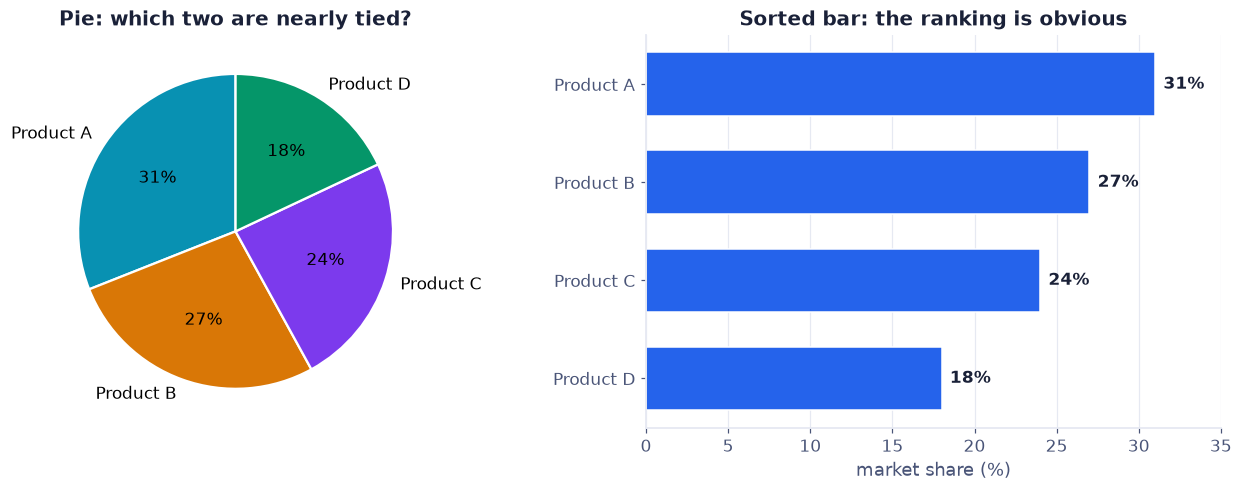

B (27) vs C (24) are hard to separate on the pie, trivial on the bar.


In [6]:
share = pd.Series({"Product A":31,"Product B":27,"Product C":24,"Product D":18})

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
a1.pie(share.values, labels=share.index, autopct="%1.0f%%", startangle=90,
       colors=CATS[:len(share)], wedgeprops=dict(edgecolor="white", linewidth=1.5))
a1.set_title("Pie: which two are nearly tied?")

s = share.sort_values()
a2.barh(s.index, s.values, color=BLUE, edgecolor="white", height=0.65)
a2.set_title("Sorted bar: the ranking is obvious"); a2.set_xlabel("market share (%)")
a2.set_xlim(0, 35); a2.grid(axis="y", visible=False)
for i,v in enumerate(s.values): a2.text(v+0.5, i, f"{v}%", va="center", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()
print("B (27) vs C (24) are hard to separate on the pie, trivial on the bar.")

## 👥 Real-World Example: An Employee Survey
A survey of 400 employees, all categorical. First a plain **bar chart** ranks the departments by headcount. Then a **grouped bar** of satisfaction by work mode does the real work: it lines up the Low/Medium/High counts side by side for each arrangement, and the pattern jumps out, remote and hybrid staff report High satisfaction far more often than onsite staff.

department headcount: {'Engineering': 113, 'Sales': 96, 'Support': 85, 'Marketing': 61, 'Operations': 45}
satisfaction by work mode:
satisfaction  Low  Medium  High
work_mode                      
Hybrid         17      56    68
Onsite         47      48    27
Remote         19      51    67


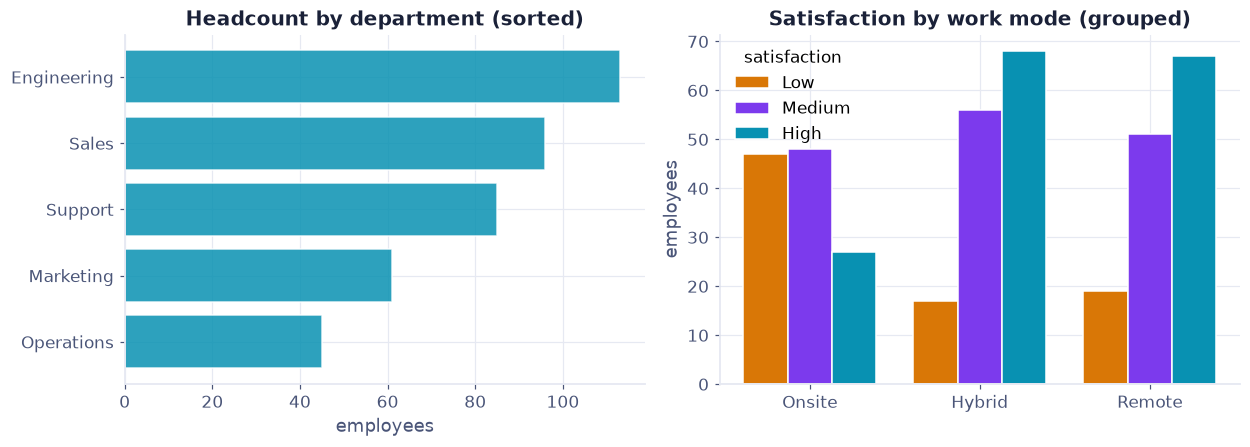

In [7]:
# --- Real-World beat: bar chart and grouped bar on survey categories ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    survey = pd.read_excel("../../data/charts-for-categorical-data--employee_survey.xlsx", sheet_name="Data")
except FileNotFoundError: survey = pd.read_excel(BASE+"charts-for-categorical-data--employee_survey.xlsx", sheet_name="Data")
dept = survey.department.value_counts()
ct = pd.crosstab(survey.work_mode, survey.satisfaction)[["Low","Medium","High"]]
print("department headcount:", dept.to_dict())
print("satisfaction by work mode:"); print(ct.to_string())
fig, ax = plt.subplots(1, 2, figsize=(11.5,4.2))
ax[0].barh(dept.index[::-1], dept.values[::-1], color=CYAN, alpha=0.85, edgecolor="white")
ax[0].set_title("Headcount by department (sorted)"); ax[0].set_xlabel("employees")
modes = ["Onsite","Hybrid","Remote"]; levels = ["Low","Medium","High"]; cols = [AMBER, PURPLE, CYAN]
x = np.arange(len(modes)); w = 0.26
for j, lvl in enumerate(levels):
    ax[1].bar(x + (j-1)*w, [ct.loc[m, lvl] for m in modes], w, label=lvl, color=cols[j], edgecolor="white")
ax[1].set_xticks(x); ax[1].set_xticklabels(modes); ax[1].legend(title="satisfaction")
ax[1].set_title("Satisfaction by work mode (grouped)"); ax[1].set_ylabel("employees")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>The <b>bar chart</b> is the default for categories; bars have <b>gaps</b> and must start at <b>zero</b>.</li>
<li><b>Horizontal, sorted</b> bars handle long labels and many categories cleanly.</li>
<li><b>Grouped</b> bars compare series precisely; <b>stacked</b> bars show totals but hide inner comparisons.</li>
<li>A <b>truncated axis</b> exaggerates differences, one of the most common ways charts mislead.</li>
<li>A <b>sorted bar</b> usually beats a <b>pie</b>: we read length far better than angle.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>